In [ ]:
!pip install scikit-learn==1.8.0 imbalanced-learn==0.14.1 xgboost==3.2.0 pandas==3.0.2 numpy==2.4.4 streamlit==1.56.0 plotly==6.7.0

In [ ]:
# Importing libraries

import pickle
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

from xgboost import XGBClassifier

In [ ]:
#!/bin/bash
!kaggle datasets download kartik2112/fraud-detection

Dataset URL: https://www.kaggle.com/datasets/kartik2112/fraud-detection
License(s): CC0-1.0
fraud-detection.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
# Unzip the file
!unzip fraud-detection.zip

Archive:  fraud-detection.zip
replace fraudTest.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fraudTest.csv           
replace fraudTrain.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fraudTrain.csv          


In [ ]:
ls

best_fraud_model.pkl  fraudTest.csv   sample_data/
fraud-detection.zip   fraudTrain.csv


In [ ]:
# Load Data
train_df = pd.read_csv("fraudTrain.csv")
test_df = pd.read_csv("fraudTest.csv")

df = pd.concat([train_df, test_df], ignore_index=True)

print("Dataset shape:", df.shape)
print(df["is_fraud"].value_counts())

df.head()

Dataset shape: (1852394, 23)
is_fraud
0    1842743
1       9651
Name: count, dtype: int64


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
# Feature Engineering

def calculate_distance(lat1, lon1, lat2, lon2):
    """
    Haversine distance between customer and merchant location.
    """
    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return 6371 * c


def create_features(data):
    data = data.copy()

    data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"])
    data["dob"] = pd.to_datetime(data["dob"])

    data["transaction_hour"] = data["trans_date_trans_time"].dt.hour
    data["transaction_day"] = data["trans_date_trans_time"].dt.dayofweek
    data["is_weekend"] = data["transaction_day"].isin([5, 6]).astype(int)

    data["age"] = (
        data["trans_date_trans_time"].dt.year - data["dob"].dt.year
    )

    data["amount_log"] = np.log1p(data["amt"])

    data["distance_km"] = calculate_distance(
        data["lat"],
        data["long"],
        data["merch_lat"],
        data["merch_long"]
    )

    return data

df = create_features(df)
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day,is_weekend,age,amount_log,distance_km
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,1325376018,36.011293,-82.048315,0,0,1,0,31,1.786747,78.597568
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,1325376044,49.159047,-118.186462,0,0,1,0,41,4.684259,30.212176
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,1325376051,43.150704,-112.154481,0,0,1,0,57,5.398660,108.206083
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,1325376076,47.034331,-112.561071,0,0,1,0,52,3.828641,95.673231
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,1325376186,38.674999,-78.632459,0,0,1,0,33,3.760269,77.556744


In [ ]:
# Select Features -  Define X and y

numeric_features = [
    "amt",
    "amount_log",
    "city_pop",
    "transaction_hour",
    "transaction_day",
    "is_weekend",
    "age",
    "distance_km"
]

categorical_features = [
    "category",
    "gender",
    "state",
    "job"
]

feature_columns = numeric_features + categorical_features

X = df[feature_columns]
y = df["is_fraud"]
X.head()

,amt,amount_log,city_pop,transaction_hour,transaction_day,is_weekend,age,distance_km,category,gender,state,job
0,4.97,1.786747,3495,0,1,0,31,78.597568,misc_net,F,NC,"Psychologist, counselling"
1,107.23,4.684259,149,0,1,0,41,30.212176,grocery_pos,F,WA,Special educational needs teacher
2,220.11,5.398660,4154,0,1,0,57,108.206083,entertainment,M,ID,Nature conservation officer
3,45.00,3.828641,1939,0,1,0,52,95.673231,gas_transport,M,MT,Patent attorney
4,41.96,3.760269,99,0,1,0,33,77.556744,misc_pos,M,VA,Dance movement psychotherapist


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training fraud rate:", y_train.mean())
print("Testing fraud rate:", y_test.mean())

Training fraud rate: 0.005209836643765363
Testing fraud rate: 0.005210548932301732


In [ ]:
# Preprocessing

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [ ]:
# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=12,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
}


In [ ]:
# Train And Evaluate

results = []
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("smote", SMOTE(random_state=42)),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    scores = pipeline.predict_proba(X_test)[:, 1]

    avg_precision = average_precision_score(y_test, scores)
    roc_auc = roc_auc_score(y_test, scores)

    results.append({
        "model": name,
        "average_precision": avg_precision,
        "roc_auc": roc_auc
    })

    trained_models[name] = pipeline


leaderboard = pd.DataFrame(results).sort_values(
    by="average_precision",
    ascending=False
).reset_index(drop=True)

print("\nModel Leaderboard:")
print(leaderboard)



Training Logistic Regression...

Training Random Forest...

Training XGBoost...

Model Leaderboard:
                 model  average_precision   roc_auc
0              XGBoost           0.706634  0.993209
1        Random Forest           0.682135  0.981562
2  Logistic Regression           0.178526  0.938435


In [ ]:
# Choose Best Model

best_model_name = leaderboard.loc[0, "model"]
best_model = trained_models[best_model_name]

print("\nBest Model:", best_model_name)



Best Model: XGBoost


In [ ]:
# Best Threshold
y_probs = best_model.predict_proba(X_test)[:, 1]

fraud_only_probs = y_probs[y_test == 1]

average_fraud_prob = np.mean(fraud_only_probs)

print(f"Number of fraud cases analyzed: {len(fraud_only_probs)}")
print(f"The average risk score for a fraudster: {average_fraud_prob:.4f}")
best_threshold = float(average_fraud_prob)
print(f"Best Threshold : {best_threshold:.4f}")

Number of fraud cases analyzed: 2413
The average risk score for a fraudster: 0.8640
Best Threshold : 0.8640


In [ ]:
# Confusion Matrix

final_predictions = (y_probs >= best_threshold).astype(int)

cm = confusion_matrix(y_test, final_predictions)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, final_predictions))


Confusion Matrix:
[[459387   1299]
 [   500   1913]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    460686
           1       0.60      0.79      0.68      2413

    accuracy                           1.00    463099
   macro avg       0.80      0.89      0.84    463099
weighted avg       1.00      1.00      1.00    463099



In [ ]:
# Performance Metrics
precision = precision_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions)
avg_precision = average_precision_score(y_test, y_probs)

print(f"--- Performance at Threshold {best_threshold:.4f} ---")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Avg Precision (AUC-PR): {avg_precision:.4f}")

--- Performance at Threshold 0.8640 ---
Precision: 0.5956
Recall:    0.7928
F1 Score:  0.6802
Avg Precision (AUC-PR): 0.7066


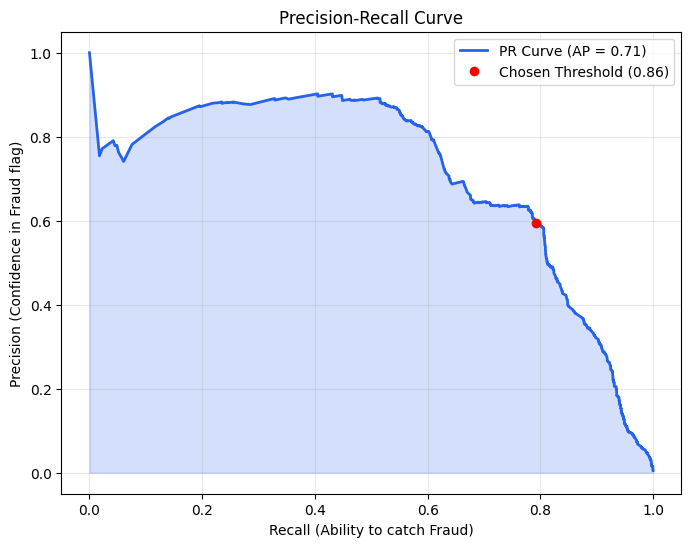

In [ ]:
# Precision Recall Curve
from matplotlib import pyplot as plt
precisions, recalls, thresholds_curve = precision_recall_curve(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='#2563eb', lw=2, label=f'PR Curve (AP = {avg_precision:.2f})')
plt.fill_between(recalls, precisions, alpha=0.2, color='#2563eb')

idx = np.argmin(np.abs(thresholds_curve - best_threshold))
plt.plot(recalls[idx], precisions[idx], 'ro', label=f'Chosen Threshold ({best_threshold:.2f})')

plt.xlabel('Recall (Ability to catch Fraud)')
plt.ylabel('Precision (Confidence in Fraud flag)')
plt.title('Precision-Recall Curve')
plt.legend(loc="upper right")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Save Pickle File

model_package = {
    "model_name": best_model_name,
    "model": best_model,
    "threshold": float(best_threshold),
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "leaderboard": leaderboard,
    "confusion_matrix": cm
}

with open("best_fraud_model.pkl", "wb") as file:
    pickle.dump(model_package, file)

print("\nModel saved successfully as best_fraud_model.pkl")


Model saved successfully as best_fraud_model.pkl


In [ ]:
# Downloading Pickle from Colab

from google.colab import files

files.download("best_fraud_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>